<img alt="FinanceScenarios" src="/assets/images/projects/financescenarios/banner.png" width="100%" />


# FinanceScenarios -- 3. Portfolio

> What would happen to your money? Pick a mix of investments, put it through every simulated
> future, and read the typical result, the bad years and the chance the money lasts.

The `Portfolio` layer never simulates anything. It reads a `ScenarioSet` that was already simulated and combines the
chosen factors into the value of one *portfolio*, with rebalancing, saving and
withdrawing, fees and risk measures. This notebook simulates once and then explores every part of it.

In [1]:
import polars as pl

from financescenarios import Portfolio, Scenarios, list_presets

pl.Config.set_tbl_width_chars(200)  # wide enough that long factor names are not wrapped
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_rows(20)

scenarios = Scenarios.from_profiles(settings="default", factor_set="us_only")
result = scenarios.simulate(n_simulations=1_000)
print(f"{result.n_simulations} scenarios, {len(result.dates) - 1} monthly steps")

1000 scenarios, 60 monthly steps


## Ready-made portfolios

> Fourteen well-known mixes ship with the package, so you can start without choosing weights.

In [2]:
list_presets(kind="portfolios")

kind,id,use_with,name,description
str,str,str,str,str
"""portfolios""","""all_weather""","""Portfolio.from_preset(result, preset=""all_weather"")""","""All Weather""","""Ray Dalio's mix for every economic climate: 30% US stocks, 55% long US Treasurie…"
"""portfolios""","""balanced_60_40""","""Portfolio.from_preset(result, preset=""balanced_60_40"")""","""60/40 Balanced""","""The textbook mix: 60% US stocks and 40% US Treasury bonds."""
"""portfolios""","""barbell""","""Portfolio.from_preset(result, preset=""barbell"")""","""Barbell""","""Nassim Taleb's barbell: 80% Treasury bills, 20% small-cap and growth stocks, not…"
"""portfolios""","""bogleheads_three_fund""","""Portfolio.from_preset(result, preset=""bogleheads_three_fund"")""","""Bogleheads Three-Fund""","""The Bogleheads' three funds: 40% US stocks, 20% international stocks and 40% US …"
"""portfolios""","""buffett_90_10""","""Portfolio.from_preset(result, preset=""buffett_90_10"")""","""Buffett's 90/10""","""Warren Buffett's advice for his estate: 90% in an S&P 500 fund and 10% in Treasu…"
"""portfolios""","""conservative_income""","""Portfolio.from_preset(result, preset=""conservative_income"")""","""Conservative Multi-Country Bonds""","""Mostly US, euro-area and UK government bonds, with 10% in US stocks for growth. …"
"""portfolios""","""endowment_model""","""Portfolio.from_preset(result, preset=""endowment_model"")""","""Endowment Model""","""A university-endowment mix with 40% in listed stand-ins for private markets. Nee…"
"""portfolios""","""global_60_40""","""Portfolio.from_preset(result, preset=""global_60_40"")""","""Global 60/40""","""The 60/40 spread across countries: US, European and emerging-market stocks; US, …"
"""portfolios""","""global_equity_growth""","""Portfolio.from_preset(result, preset=""global_equity_growth"")""","""Global Equity Growth""","""All stocks, spread across the US, Europe, Japan, emerging markets and China, til…"


`Portfolio.from_preset(result, preset="balanced_60_40")` builds the classic 60/40: 60% broad US stocks and 40% US government
bonds. The bonds are priced as a Treasury bond fund with a *duration* of 5.4 years: it follows the
simulated 10-year yield and loses value when that yield rises. `compute` puts 100,000 through every scenario,
*rebalancing* back to 60/40 every 12 monthly steps.

In [3]:
portfolio = Portfolio.from_preset(result, preset="balanced_60_40")
values = portfolio.compute(initial_value=100_000, rebalance_every=12)

values.describe()

factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""portfolio""","""Portfolio""","""portfolio""","""annualized""",null,0.087892,0.009015,0.160449
"""us_broad_value""","""US Broad Value""","""holding""","""annualized""",null,0.087892,0.009015,0.160449
"""united_states_long_rate_value""","""United States Long Rate Value""","""holding""","""annualized""",null,0.087892,0.009015,0.160449


`describe()` reads the result as an annualized return. The two holdings show the portfolio's own rate because the
yearly rebalance trades them back to 60/40 at the end. `levels=True` reads it in money, and `plot(levels=True)` draws
it.

In [4]:
values.describe(levels=True)

factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""portfolio""","""Portfolio""","""portfolio""","""native""",100000.0,155194.373778,104589.611325,210441.03397
"""us_broad_value""","""US Broad Value""","""holding""","""native""",60000.0,93116.624267,62753.766795,126264.620382
"""united_states_long_rate_value""","""United States Long Rate Value""","""holding""","""native""",40000.0,62077.749511,41835.84453,84176.413588


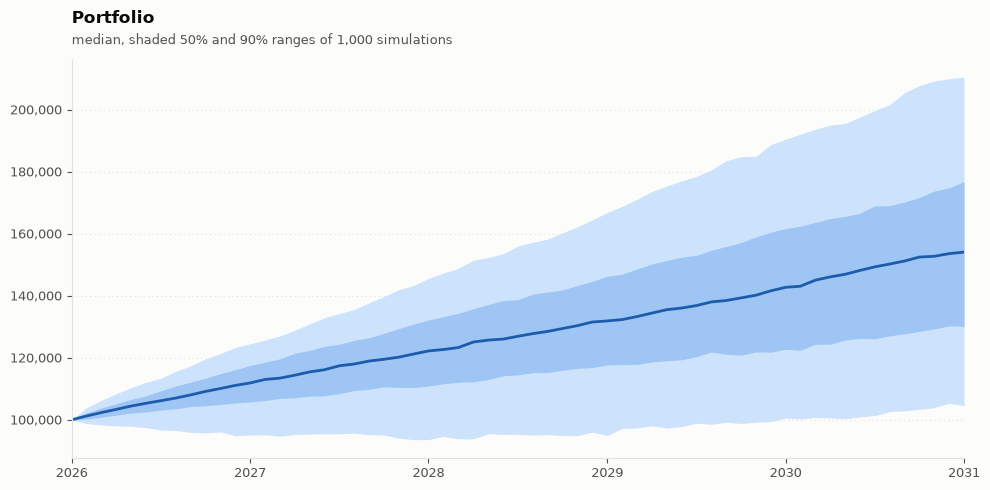

In [5]:
values.plot(levels=True)

## Risk metrics

> How bad do the bad cases get?

`risk_metrics()` reads the latest `compute()`: the *maximum drawdown* (worst dip along the way) at
several percentiles, the 95% *Value at Risk* (the five-year loss 95 of 100 scenarios stay
within) and *CVaR* (the average loss in the worst 5), the
yearly volatility and the chance of ending below the start. Losses are positive numbers, so a negative VaR means even
the worst 1 in 20 scenarios still gained.

In [6]:
risk = portfolio.risk_metrics()

print(f"worst dip, median scenario:  {risk.max_drawdown_percentiles['50']:.1%}")
print(f"worst dip, 1 in 20:        {risk.max_drawdown_percentiles['5']:.1%}")
print(f"95% VaR, five years:       {risk.value_at_risk_95:.1%}")
print(f"95% CVaR, five years:      {risk.conditional_value_at_risk_95:.1%}")
print(f"yearly volatility:         {risk.annualized_volatility:.1%}")
print(f"chance of a loss:          {risk.probability_of_loss:.1%}")

worst dip, median scenario:  -11.8%
worst dip, 1 in 20:        -25.3%
95% VaR, five years:       -4.6%
95% CVaR, five years:      4.6%
yearly volatility:         8.8%
chance of a loss:          3.3%


## A one-call summary with a goal

`summary(goal_value=...)` adds the chance of reaching a goal and the median year it is reached, alongside the risk
metrics and the spread of the end value.

In [7]:
summary = portfolio.summary(goal_value=150_000)
goal = summary.goal_probability
if goal is not None:  # filled in because a goal_value was given
    print(f"chance of reaching 150,000: {goal.probability:.0%}")
    print(f"median year reached:        {goal.median_year_reached:.1f}")
print(f"median end value:           {summary.withdrawal_success.terminal_value_percentiles['50']:,.0f}")

chance of reaching 150,000: 63%
median year reached:        3.4
median end value:           154,044


## Your own weights

> Any mix of the simulated stocks, bonds, currencies and commodities works, as long as the weights
> add up to 1.

`compute(weights)` takes a factor name per holding. `result.factors("equities")` and friends list what is available.
A bond holding needs `durations` to be priced as a bond fund; without it, a rate is rolled like cash. `fee_rate`
charges a yearly cost, here 0.2%, and `rebalance_band` rebalances only when a weight drifts more than 5 points.

In [8]:
custom = portfolio.compute(
    {"us_broad": 0.5, "united_states_long_rate": 0.3, "gold": 0.2},
    initial_value=100_000,
    durations={"united_states_long_rate": 5.4},
    fee_rate=0.002,
    rebalance_band=0.05,
)
custom.describe()

factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""portfolio""","""Portfolio""","""portfolio""","""annualized""",null,0.082378,0.012285,0.151004
"""us_broad_value""","""US Broad Value""","""holding""","""annualized""",null,0.084727,0.011163,0.156574
"""united_states_long_rate_value""","""United States Long Rate Value""","""holding""","""annualized""",null,0.078612,0.011641,0.145534
"""gold_value""","""Gold Value""","""holding""","""annualized""",null,0.080564,-0.000073,0.158166


`weight_drift()` shows how far each holding wandered from its target between rebalances, here for the custom mix.

In [9]:
import numpy as np

drift = portfolio.weight_drift()
for name, gap in drift.items():
    print(f"{name:28s} largest drift: {np.abs(gap).max():.1%}")

us_broad                     largest drift: 5.0%
united_states_long_rate      largest drift: 5.0%
gold                         largest drift: 5.0%


## Saving and withdrawing

> Add money for a while, then take money out, and see in how many scenarios it lasts.

`portfolio.cashflow_rule(amount, every_years, start_year, end_year)` describes a recurring deposit (positive) or
withdrawal (negative) in years. Here: 100,000 to start, 5,000 added at the start of each of the first two years, then
30,000 taken out every year from year 2. `withdrawal_success()` gives the share of scenarios in which the money never runs out.

In [10]:
plan = [
    portfolio.cashflow_rule(5_000, every_years=1, start_year=0, end_year=1),
    portfolio.cashflow_rule(-30_000, every_years=1, start_year=2),
]
funded = portfolio.compute(initial_value=100_000, rebalance_every=12, cashflow_rules=plan)

success = portfolio.withdrawal_success()
print(f"money lasts in {success.success_rate:.0%} of scenarios")
print(f"median end value: {success.terminal_value_percentiles['50']:,.0f}")
print(f"median year it runs out, where it does: {success.median_depletion_year}")

money lasts in 89% of scenarios
median end value: 36,171
median year it runs out, where it does: 5.0


With `inflation_factor="united_states_inflation"` every amount is read in today's money and grows with each scenario's
own inflation, so a withdrawal keeps its buying power.

In [11]:
real_plan = portfolio.compute(
    initial_value=100_000, rebalance_every=12, cashflow_rules=plan, inflation_factor="united_states_inflation"
)
print(f"money lasts in {portfolio.withdrawal_success().success_rate:.0%} of scenarios with inflation-linked amounts")

money lasts in 74% of scenarios with inflation-linked amounts


## Glidepaths

> A mix that shifts from stocks to bonds as a target date nears, as a target-date fund does.

A *glidepath* is a list of `GlidepathCheckpoint`s, each a year and the weights to hold then; in
between the weights move in a straight line. `compute_glidepath` rebalances towards the current point. The shipped
`target_date_glidepath` preset is one too. In money (`levels=True`) the shift shows: 90,000 starts in stocks, and by
year 5 most of the value sits in bonds.

In [12]:
from financescenarios import GlidepathCheckpoint

checkpoints = [
    GlidepathCheckpoint(year=0, weights={"us_broad": 0.9, "united_states_long_rate": 0.1}),
    GlidepathCheckpoint(year=5, weights={"us_broad": 0.4, "united_states_long_rate": 0.6}),
]
glidepath = portfolio.compute_glidepath(
    checkpoints, initial_value=100_000, rebalance_every=1, durations={"united_states_long_rate": 5.4}
)
glidepath.describe(levels=True)

factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""portfolio""","""Portfolio""","""portfolio""","""native""",100000.0,155920.554517,100209.150406,219096.810585
"""us_broad_value""","""US Broad Value""","""holding""","""native""",90000.0,62368.221807,40083.660163,87638.724234
"""united_states_long_rate_value""","""United States Long Rate Value""","""holding""","""native""",10000.0,93552.33271,60125.490244,131458.086351


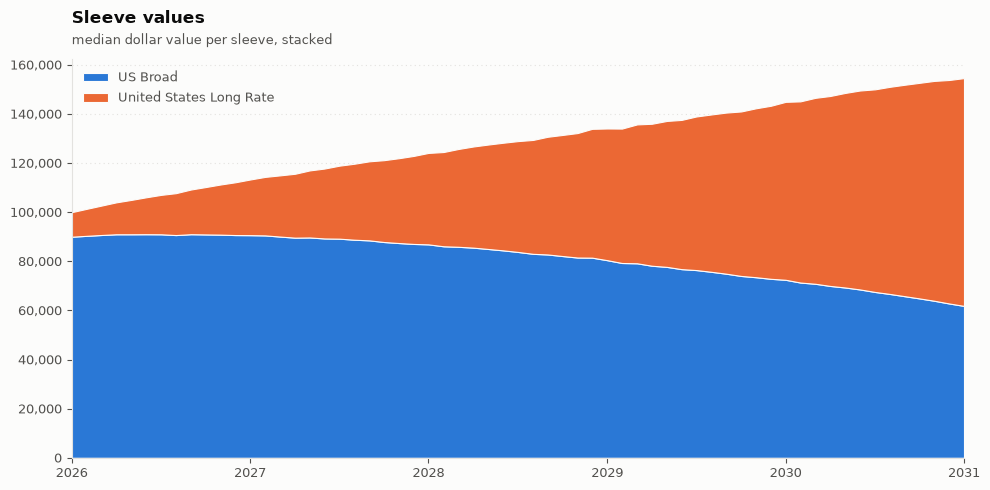

In [13]:
glidepath.plot(kind="sleeves")

## Next: `4. Portfolio Analysis`

Backtesting the same mix on history, measuring what really drives it (Fama-French factor exposure), and comparing two
portfolios head to head.